# Set up notebook and define functions

In [ ]:
import numpy as np
import xarray as xr 
import matplotlib.pyplot as plt
import matplotlib as mpl

import importlib # allows us to reload imported modules without restarting the whole notebook.

# read in util files
util_path = '../util_files/'
import sys
sys.path.append(util_path)

import P_to_GPH_ncol
importlib.reload(P_to_GPH_ncol)

import Interpolate_lev_z
importlib.reload(Interpolate_lev_z)

In [2]:
def converta_omega_to_w(omega,T,pressure): # Convert Pa/s to m/s (take care with units!)
    """_summary_
    Takes in:
    
    omega - vertical velocity in Pa/s
    T - temperature in Kelvin
    pressure - atmospheric pressure in hPa (take care with units!)
    
    returns vertical velocity data array in m/s
    """
    
    # Calculate mass density: kg m^-3
    # Conversion constants
    R = 287.058 # J/ kg^-1 K^-1 => m^2 s^-2 K^-1
    to_Pa = 100 # convert from hPa to Pa. Pa => kg m^-1 s^-2
    rho = pressure*to_Pa/(R*T) # Units: kg m^-1 s^-2 * m^-2 s^2 K * K^-1 => kg m^-3

    g = 9.80665 # m s^-2
    w = -omega/(rho*g) # Units: kg m^-1 s^-2 * s^-1 * kg^-1 m^3 * m^-1 s^2 => m s^-1
    
    return w

In [3]:
# FFT function

def fft_of_ds(data_for_fft,data_resolution):
    
    # Perform 1d fft
    fft_result = np.fft.fft(data_for_fft)
    print('performed fft')
    
    # create spectral dimension (named like this as it could be both associated with space or time)
    spectral_dimension = np.fft.fftfreq(len(data_for_fft),data_resolution)
    ds_fft = xr.DataArray(np.abs(fft_result)**2, dims=['spectral_dimension'], coords={'spectral_dimension':spectral_dimension})
    
    ds_fft.loc[{'spectral_dimension':0}] = 0 # Remove DC component
    ds_fft_sorted = ds_fft.sortby(ds_fft.spectral_dimension).where(ds_fft.spectral_dimension >= 0,drop=True) # Keep only positive wavenumbers.
    
    return ds_fft_sorted

In [4]:
def create_window(x):
    """
    x is physical dimension of dataset
    """
    # Create a 2D window using outer product of 1D window functions
    window_1d = np.hanning(len(x))  # 1D Hanning window

    ds_window = xr.DataArray(window_1d,dims=['physical_dimension'],coords={'physical_dimension':x})
    
    return ds_window


In [34]:
mpl.rcParams['font.size'] = 15

In [35]:
CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

# Process

I used this part of the notebook to prepare my data for vertical wavenumber spectrum calculations.

Namely
- Compute vertical velocity w from OMEGA and T
- Calculate geometric altitude from temperature and pressure
- Interpolate data to uniform geometric altitude for suitability for FFT calculations.

This has been curated for the CONUS-RR simulations, so will need to be adapted for any other uses.
Other users of this notebook can take examples from this code.

In [6]:
path_in = '/uolstore/Research/b/b0252/Data/cam6_2_011_CONUS/CONUS_RR_PROCESSED_DATA/reduced_data/1D_timeseries/'

ds1 = xr.open_mfdataset(path_in + '*_nonrr_*2010-06-01*').squeeze()[['OMEGA','T']]  # squeeze gets rid of any dimensions of size 1 which are not used
ds2 = xr.open_mfdataset(path_in + '*_rr_*2010-06-01*').squeeze()[['OMEGA','T']]

In [7]:
ds1

<xarray.Dataset> Size: 22kB
Dimensions:  (time: 24, lev: 110)
Coordinates:
  * lev      (lev) float64 880B 6.14e-06 9.453e-06 1.455e-05 ... 976.3 992.6
  * time     (time) object 192B 2010-06-01 00:00:00 ... 2010-06-01 23:00:00
Data variables:
    OMEGA    (time, lev) float32 11kB dask.array<chunksize=(24, 110), meta=np.ndarray>
    T        (time, lev) float32 11kB dask.array<chunksize=(24, 110), meta=np.ndarray>
Attributes: (12/13)
    ne:                30
    np:                4
    Conventions:       CF-1.0
    source:            CAM
    case:              FWmaHIST_ne30pg3_ne30pg3_mg17_no_conus_gravity_waves
    logname:           nadavis
    ...                ...
    initial_file:      /glade/scratch/nadavis/cesm2_inputs/f.e21.FWHIST.110L....
    topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/se/ne30n...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  hour_1
    history:           Tue Jul 22 11:16:42 2025: ncks -d ncol,32041 -v T,OMEG...
    NCO:               netCDF Operators version 5.1.4 (Homepage = http://nco....

In [8]:
# Compute vertical velocity
ds1['w'] = converta_omega_to_w(ds1['OMEGA'],ds1['T'],ds1['lev'])
ds2['w'] = converta_omega_to_w(ds2['OMEGA'],ds2['T'],ds2['lev']) 


In [9]:
import P_to_GPH_ncol
importlib.reload(P_to_GPH_ncol)

<module 'P_to_GPH_ncol' from '/localhome/phymku/CONUS_WACCM_RR/spectra/../util_files/P_to_GPH_ncol.py'>

In [10]:
ds1 = P_to_GPH_ncol.P_to_GPH_ncol(ds1) # Takes in dataset, and returns the whole dataset but with z and gph as variables

Integrating it, 23  ncol  0  lev  0  progress  99.13  %   
That took  23.28 seconds


In [11]:
ds1

<xarray.Dataset> Size: 86kB
Dimensions:  (time: 24, lev: 110)
Coordinates:
  * lev      (lev) float64 880B 6.14e-06 9.453e-06 1.455e-05 ... 976.3 992.6
  * time     (time) object 192B 2010-06-01 00:00:00 ... 2010-06-01 23:00:00
Data variables:
    OMEGA    (time, lev) float32 11kB dask.array<chunksize=(24, 110), meta=np.ndarray>
    T        (time, lev) float32 11kB dask.array<chunksize=(24, 110), meta=np.ndarray>
    w        (time, lev) float64 21kB dask.array<chunksize=(24, 110), meta=np.ndarray>
    gph      (time, lev) float64 21kB 136.5 129.4 122.9 ... 0.3082 0.1417 0.0
    z        (time, lev) float64 21kB 139.5 132.1 125.3 ... 0.3082 0.1417 0.0
Attributes: (12/13)
    ne:                30
    np:                4
    Conventions:       CF-1.0
    source:            CAM
    case:              FWmaHIST_ne30pg3_ne30pg3_mg17_no_conus_gravity_waves
    logname:           nadavis
    ...                ...
    initial_file:      /glade/scratch/nadavis/cesm2_inputs/f.e21.FWHIST.110L....
    topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/se/ne30n...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  hour_1
    history:           Tue Jul 22 11:16:42 2025: ncks -d ncol,32041 -v T,OMEG...
    NCO:               netCDF Operators version 5.1.4 (Homepage = http://nco....

In [12]:
import Interpolate_lev_z
importlib.reload(Interpolate_lev_z)

<module 'Interpolate_lev_z' from '/localhome/phymku/CONUS_WACCM_RR/spectra/../util_files/Interpolate_lev_z.py'>

In [13]:
ds1_on_z = Interpolate_lev_z.interpolate_lev_to_z_ncol(ds1)

ncol not in dims
nlev, ntime 110 24
Interpolating time 0
Interpolating time 1
Interpolating time 2


Interpolating time 3
Interpolating time 4
Interpolating time 5
Interpolating time 6
Interpolating time 7
Interpolating time 8
Interpolating time 9
Interpolating time 10
Interpolating time 11
Interpolating time 12
Interpolating time 13
Interpolating time 14
Interpolating time 15
Interpolating time 16
Interpolating time 17
Interpolating time 18
Interpolating time 19
Interpolating time 20
Interpolating time 21
Interpolating time 22
Interpolating time 23
That took 0.0079 seconds
Completed 100.000 %
Interpolating took 0.2497 seconds


In [14]:
ds2 = P_to_GPH_ncol.P_to_GPH_ncol(ds2)

Integrating it, 23  ncol  0  lev  0  progress  99.13  %   
That took  23.36 seconds


In [15]:
ds2

<xarray.Dataset> Size: 86kB
Dimensions:  (time: 24, lev: 110)
Coordinates:
  * lev      (lev) float64 880B 6.14e-06 9.453e-06 1.455e-05 ... 976.3 992.6
  * time     (time) object 192B 2010-06-01 00:00:00 ... 2010-06-01 23:00:00
Data variables:
    OMEGA    (time, lev) float32 11kB dask.array<chunksize=(24, 110), meta=np.ndarray>
    T        (time, lev) float32 11kB dask.array<chunksize=(24, 110), meta=np.ndarray>
    w        (time, lev) float64 21kB dask.array<chunksize=(24, 110), meta=np.ndarray>
    gph      (time, lev) float64 21kB 136.2 130.2 124.9 ... 0.3106 0.1428 0.0
    z        (time, lev) float64 21kB 139.2 132.9 127.4 ... 0.3106 0.1428 0.0
Attributes: (12/13)
    ne:                0
    np:                4
    Conventions:       CF-1.0
    source:            CAM
    case:              FWmaHIST_ne0CONUSne30x8_ne0CONUSne30x8_mt12_no_conus_g...
    logname:           nadavis
    ...                ...
    initial_file:      /glade/p/cgd/amp/pel/inic/waccm-conus-FW-nlev110.i.nc
    topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/se/ne30x...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  hour_1
    history:           Tue Jul 22 11:52:33 2025: ncks -d ncol,117008 -v T,OME...
    NCO:               netCDF Operators version 5.1.4 (Homepage = http://nco....

In [16]:
ds2_on_z = Interpolate_lev_z.interpolate_lev_to_z_ncol(ds2)

ncol not in dims
nlev, ntime 110 24
Interpolating time 0
Interpolating time 1
Interpolating time 2
Interpolating time 3


Interpolating time 4
Interpolating time 5
Interpolating time 6
Interpolating time 7
Interpolating time 8
Interpolating time 9
Interpolating time 10
Interpolating time 11
Interpolating time 12
Interpolating time 13
Interpolating time 14
Interpolating time 15
Interpolating time 16
Interpolating time 17
Interpolating time 18
Interpolating time 19
Interpolating time 20
Interpolating time 21
Interpolating time 22
Interpolating time 23
That took 0.0069 seconds
Completed 100.000 %
Interpolating took 0.2038 seconds


In [17]:
ds2_on_z

<xarray.Dataset> Size: 43kB
Dimensions:  (time: 24, z: 55)
Coordinates:
  * time     (time) object 192B 2010-06-01 00:00:00 ... 2010-06-01 23:00:00
  * z        (z) float64 440B 135.0 132.5 130.0 127.5 125.0 ... 7.5 5.0 2.5 0.0
Data variables:
    OMEGA    (time, z) float32 5kB dask.array<chunksize=(1, 55), meta=np.ndarray>
    T        (time, z) float32 5kB dask.array<chunksize=(1, 55), meta=np.ndarray>
    lev      (time, z) float64 11kB 8.358e-06 9.834e-06 ... 735.7 992.6
    w        (time, z) float64 11kB dask.array<chunksize=(1, 55), meta=np.ndarray>
    gph      (time, z) float64 11kB 132.2 129.8 127.4 125.0 ... 4.996 2.499 0.0
Attributes: (12/13)
    ne:                0
    np:                4
    Conventions:       CF-1.0
    source:            CAM
    case:              FWmaHIST_ne0CONUSne30x8_ne0CONUSne30x8_mt12_no_conus_g...
    logname:           nadavis
    ...                ...
    initial_file:      /glade/p/cgd/amp/pel/inic/waccm-conus-FW-nlev110.i.nc
    topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/se/ne30x...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  hour_1
    history:           Tue Jul 22 11:52:33 2025: ncks -d ncol,117008 -v T,OME...
    NCO:               netCDF Operators version 5.1.4 (Homepage = http://nco....

In [18]:
ds1_on_z

<xarray.Dataset> Size: 43kB
Dimensions:  (time: 24, z: 55)
Coordinates:
  * time     (time) object 192B 2010-06-01 00:00:00 ... 2010-06-01 23:00:00
  * z        (z) float64 440B 135.0 132.5 130.0 127.5 125.0 ... 7.5 5.0 2.5 0.0
Data variables:
    OMEGA    (time, z) float32 5kB dask.array<chunksize=(1, 55), meta=np.ndarray>
    T        (time, z) float32 5kB dask.array<chunksize=(1, 55), meta=np.ndarray>
    lev      (time, z) float64 11kB 8.155e-06 9.285e-06 ... 734.1 992.6
    w        (time, z) float64 11kB dask.array<chunksize=(1, 55), meta=np.ndarray>
    gph      (time, z) float64 11kB 132.2 129.8 127.4 125.0 ... 4.996 2.499 0.0
Attributes: (12/13)
    ne:                30
    np:                4
    Conventions:       CF-1.0
    source:            CAM
    case:              FWmaHIST_ne30pg3_ne30pg3_mg17_no_conus_gravity_waves
    logname:           nadavis
    ...                ...
    initial_file:      /glade/scratch/nadavis/cesm2_inputs/f.e21.FWHIST.110L....
    topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/se/ne30n...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  hour_1
    history:           Tue Jul 22 11:16:42 2025: ncks -d ncol,32041 -v T,OMEG...
    NCO:               netCDF Operators version 5.1.4 (Homepage = http://nco....

# Compute Spectra

In [44]:
var = 'w'

In [17]:
ds_window = create_window(ds1_on_z.z.values)

NameError: name 'create_window' is not defined

In [18]:
ds_window

NameError: name 'ds_window' is not defined

In [45]:
# Compute spectra and append to list 

spec_list1 = []
spec_list2 = []

for i in range(24):
    temp1 = ds1_on_z[var].isel(time=i) - ds1_on_z[var].mean(dim='time') # subtract daily mean
    da_spec1 = fft_of_ds(temp1,2500) # Input - data array, resolution in meters
    
    temp2 = ds2_on_z[var].isel(time=i) - ds2_on_z[var].mean(dim='time')
    da_spec2 = fft_of_ds(temp2,2500)
    
    spec_list1.append(da_spec1)
    spec_list2.append(da_spec2)
    

performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft
performed fft


In [46]:
# concat individual spectra into single datasets 
ds_spec1 = xr.concat(spec_list1, dim='time')
ds_spec2 = xr.concat(spec_list2, dim='time')

# Plot Spectra

In [47]:
ds_spec1_mean = ds_spec1.mean(dim='time')
ds_spec1_std = ds_spec1.std(dim='time')

ds_spec2_mean = ds_spec2.mean(dim='time')
ds_spec2_std = ds_spec2.std(dim='time')

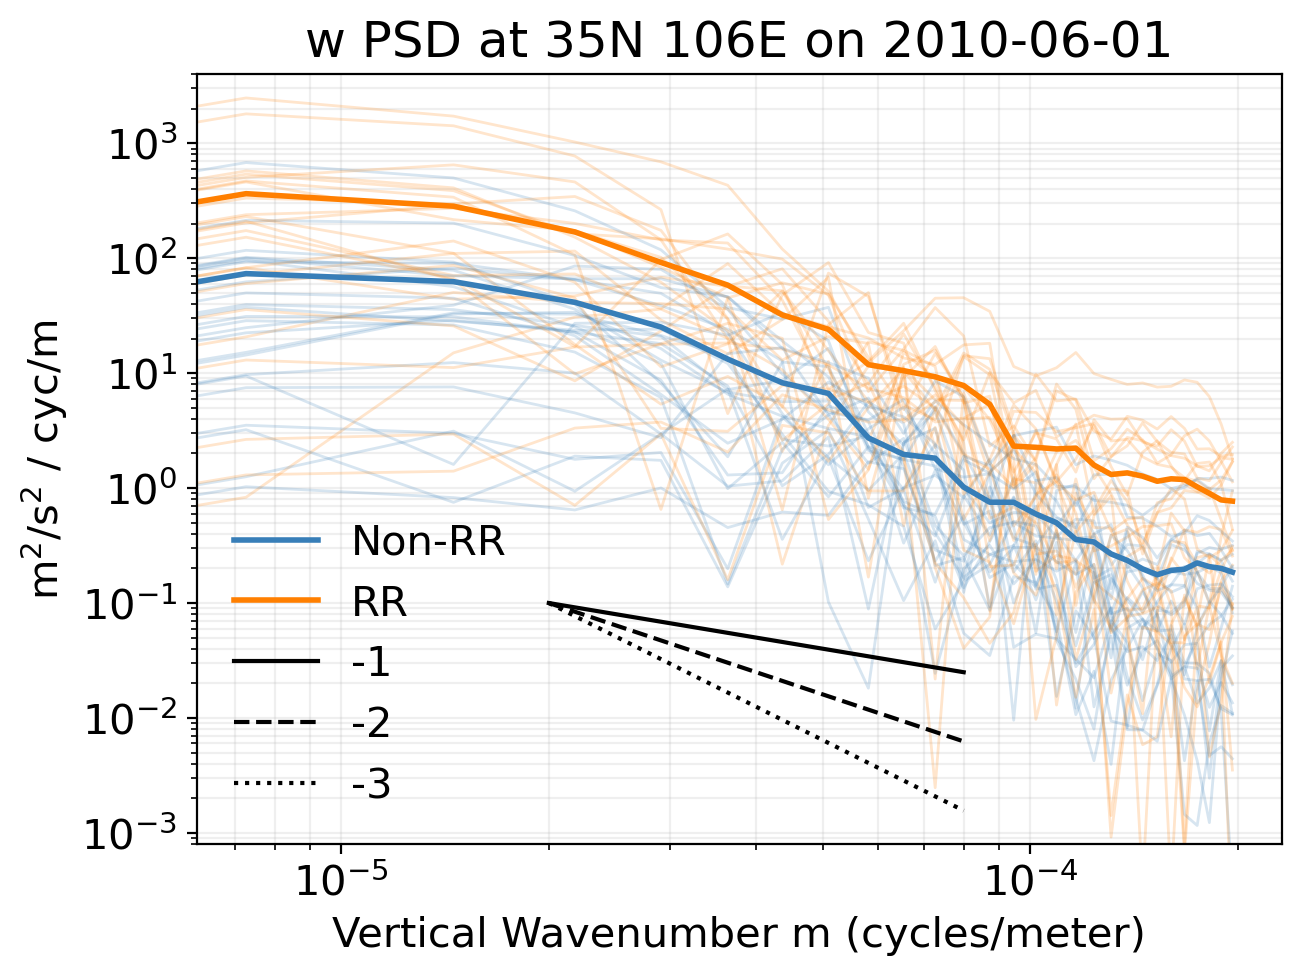

In [ ]:
fig, ax = plt.subplots(figsize=(7,5), dpi=200)


for i in range(24):
    ds_spec1.isel(time=i).plot(ax=ax, c=CB_color_cycle[0],linewidth=1,alpha=0.2)
    ds_spec2.isel(time=i).plot(ax=ax, c=CB_color_cycle[1],linewidth=1,alpha=0.2)

ds_spec1_mean.plot(ax=ax,c=CB_color_cycle[0],linewidth=2, label='Non-RR')
ds_spec2_mean.plot(ax=ax,c=CB_color_cycle[1],linewidth=2, label='RR')


ax.set_xscale('log')
ax.set_xlabel('Vertical Wavenumber m (cycles/meter)')
ax.set_yscale('log')

#
# w PSD 2010-06-01 options
#
if var == 'w':
    ax.set_ylim(8e-4,4e3)
    ax.set_title('w PSD at 35N 106E on 2010-06-01')
    ax.set_ylabel('m$^{2}$/s$^{2}$ / cyc/m')
    
    # --- Reference slopes ---
    y0 = 1e-1
    k_ref = np.logspace(np.log10(2e-5),np.log10(8e-5), 100)
    ax.plot(k_ref, y0 * (k_ref / k_ref[0])**(-1), 'k-', label='-1')
    ax.plot(k_ref, y0 * (k_ref / k_ref[0])**(-2), 'k--', label='-2')
    ax.plot(k_ref, y0 * (k_ref / k_ref[0])**(-3), 'k:', label='-3')
    ax.legend(loc='lower left', frameon=False)

#
# T PSD 2010-06-01 options
#
if var == 'T':
    ax.set_ylim(8e-1,2.5e5)
    ax.set_title('T PSD at 35N 106E on 2010-06-01')
    ax.set_ylabel('K$^2$ / cyc/m')
    
    # --- Reference slopes ---
    y0 = 5e2
    k_ref = np.logspace(np.log10(2e-5),np.log10(8e-5), 100)
    ax.plot(k_ref, y0 * (k_ref / k_ref[0])**(-1), 'k-', label='-1')
    ax.plot(k_ref, y0 * (k_ref / k_ref[0])**(-2), 'k--', label='-2')
    ax.plot(k_ref, y0 * (k_ref / k_ref[0])**(-3), 'k:', label='-3')
    ax.legend(loc='lower left', frameon=False)


ax.grid(which='both',alpha=0.2)
# h, l = ax.get_legend_handles_labels()
# ax.legend([h[-2],h[-1]], [l[-2],l[-1]],frameon=False)
# plt.savefig(f'vertical_wavenumber_spectra_{var}_20100601.png',bbox_inches='tight',dpi=200)

# Create final fig

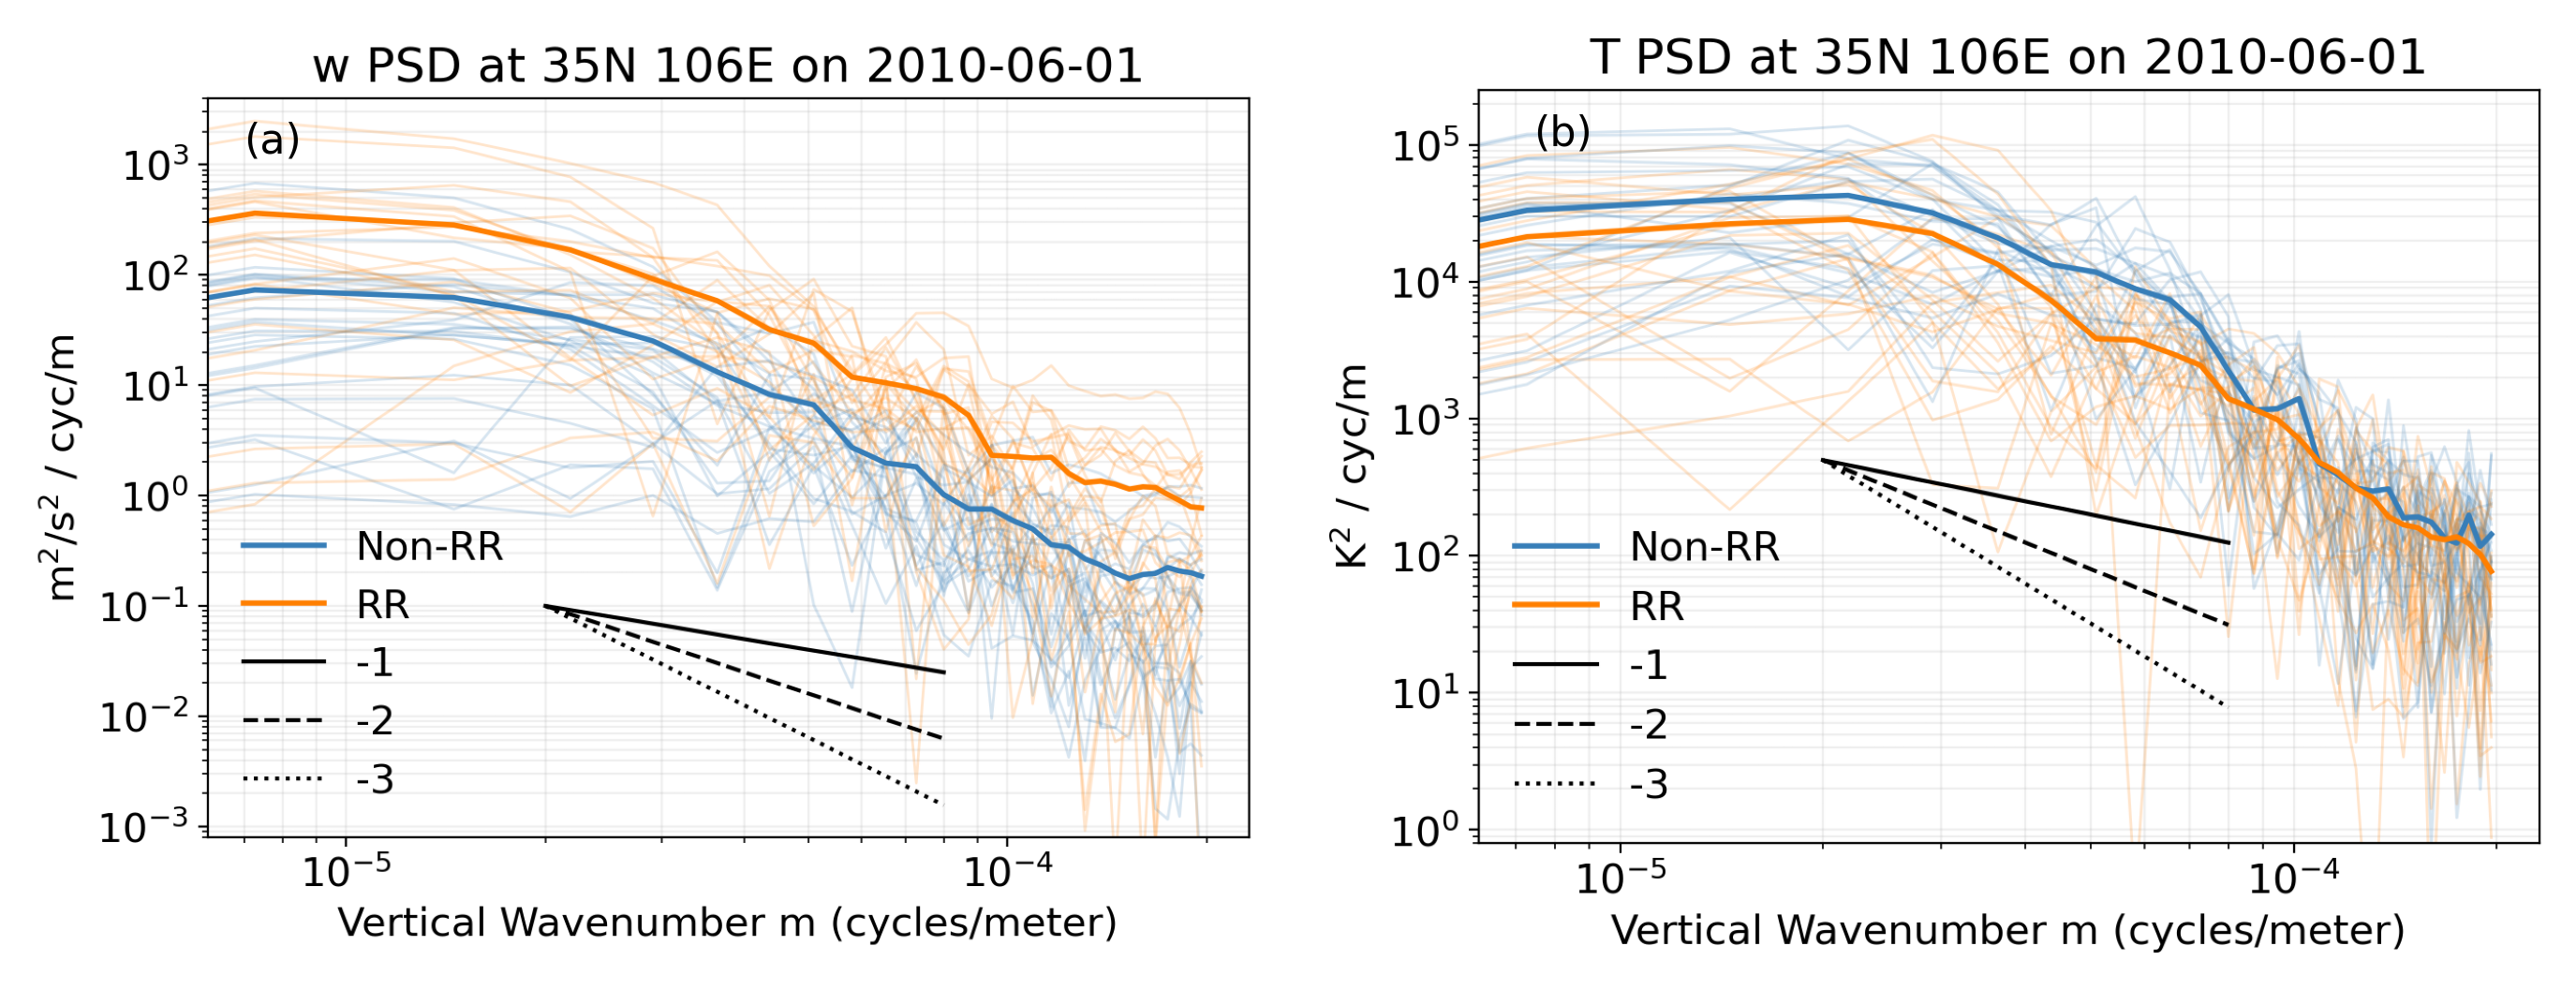

In [ ]:
import matplotlib.image as mpimg

# Load the images
img_w = mpimg.imread('vertical_wavenumber_spectra_w_20100601.png')
img_T = mpimg.imread('vertical_wavenumber_spectra_T_20100601.png')

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 7), dpi=200)

# Display the images
axes[0].imshow(img_w)
axes[0].axis('off')  # Turn off axes for the image
axes[0].text(0.18, 0.9, '(a)',fontsize=16, transform=axes[0].transAxes, va='top')

axes[1].imshow(img_T)
axes[1].axis('off')  # Turn off axes for the image
axes[1].text(0.18, 0.9, '(b)',fontsize=16, transform=axes[1].transAxes, va='top')

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig('combined_vertical_wavenumber_spectra.jpeg', bbox_inches='tight', dpi=200)
plt.show()